In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

In [5]:
print('PyTorch version:', torch.__version__)
print('Torchvision version:', torchvision.__version__)

PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu


In [6]:
# Cargamos el conjunto de datos MNIST desde torchvision
transform = transforms.ToTensor()

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                      download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                     download=True, transform=transform)

# Extraemos los datos como arrays de NumPy
x_train = trainset.data.numpy()
y_train = trainset.targets.numpy()
x_test = testset.data.numpy()
y_test = testset.targets.numpy()

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.73MB/s]


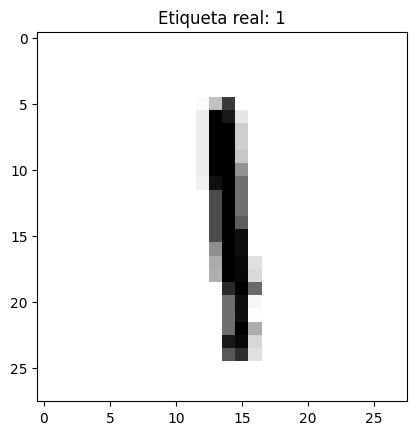

In [7]:
plt.imshow(x_train[8], cmap=plt.cm.binary)
plt.title(f'Etiqueta real: {y_train[8]}')
plt.show()

In [8]:
print(np.matrix(x_train[8]))
print('Etiqueta correspondiente:', y_train[8])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   5  63 197   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  20 254 230  24   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  20 254 254  48   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  20 254 255  4

In [9]:
print('Número de dimensiones de x_train:', x_train.ndim)
print('Forma de x_train:', x_train.shape)

Número de dimensiones de x_train: 3
Forma de x_train: (60000, 28, 28)


In [10]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [11]:
x_train /= 255.0
x_test /= 255.0

In [12]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

print('Nueva forma de x_train:', x_train.shape)
print('Nueva forma de x_test:', x_test.shape)

Nueva forma de x_train: (60000, 784)
Nueva forma de x_test: (10000, 784)


In [13]:
print(type(x_train))
print('Forma de la primera imagen aplanada:', x_train[0].shape)
print('Primeros 9 píxeles de la primera imagen:', x_train[0, 0:9])

<class 'numpy.ndarray'>
Forma de la primera imagen aplanada: (784,)
Primeros 9 píxeles de la primera imagen: [0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [14]:
print('Primera etiqueta de entrenamiento (entero):', y_train[0])

Primera etiqueta de entrenamiento (entero): 5


In [15]:
X_train = torch.from_numpy(x_train)
y_train_t = torch.from_numpy(y_train).long()

X_test = torch.from_numpy(x_test)
y_test_t = torch.from_numpy(y_test).long()

print('X_train tensor shape:', X_train.shape)
print('y_train tensor shape:', y_train_t.shape)

X_train tensor shape: torch.Size([60000, 784])
y_train tensor shape: torch.Size([60000])


In [16]:
import torch.nn as nn
import torch.optim as optim

class DenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)  # 10 dígitos (0-9)

    def forward(self, x):
        # x tiene forma (batch_size, 784)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)  # devolvemos "logits" (sin softmax)
        return x

model = DenseNet()
print(model)

DenseNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

print('Número de parámetros entrenables:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Número de parámetros entrenables: 101770


In [19]:
n_epochs = 100
loss_history = []

for epoch in range(n_epochs):
    # Modo entrenamiento
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    # Guardamos el loss para esta época
    loss_history.append(loss.item())

    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}')

Epoch 1/100, Loss: 1.4563
Epoch 2/100, Loss: 1.4254
Epoch 3/100, Loss: 1.3951
Epoch 4/100, Loss: 1.3655
Epoch 5/100, Loss: 1.3365
Epoch 6/100, Loss: 1.3083
Epoch 7/100, Loss: 1.2809
Epoch 8/100, Loss: 1.2543
Epoch 9/100, Loss: 1.2285
Epoch 10/100, Loss: 1.2036
Epoch 11/100, Loss: 1.1794
Epoch 12/100, Loss: 1.1561
Epoch 13/100, Loss: 1.1337
Epoch 14/100, Loss: 1.1120
Epoch 15/100, Loss: 1.0911
Epoch 16/100, Loss: 1.0709
Epoch 17/100, Loss: 1.0515
Epoch 18/100, Loss: 1.0329
Epoch 19/100, Loss: 1.0149
Epoch 20/100, Loss: 0.9976
Epoch 21/100, Loss: 0.9809
Epoch 22/100, Loss: 0.9649
Epoch 23/100, Loss: 0.9494
Epoch 24/100, Loss: 0.9345
Epoch 25/100, Loss: 0.9202
Epoch 26/100, Loss: 0.9064
Epoch 27/100, Loss: 0.8931
Epoch 28/100, Loss: 0.8802
Epoch 29/100, Loss: 0.8679
Epoch 30/100, Loss: 0.8559
Epoch 31/100, Loss: 0.8444
Epoch 32/100, Loss: 0.8333
Epoch 33/100, Loss: 0.8225
Epoch 34/100, Loss: 0.8121
Epoch 35/100, Loss: 0.8021
Epoch 36/100, Loss: 0.7924
Epoch 37/100, Loss: 0.7830
Epoch 38/1

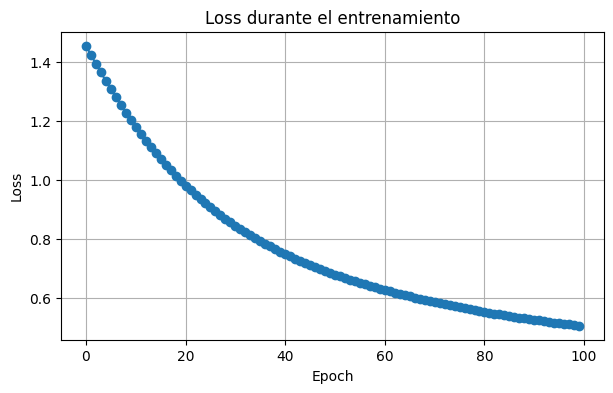

In [20]:
# Pintamos la función de pérdida vs. las épocas
plt.figure(figsize=(7,4))
plt.plot(loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss durante el entrenamiento")
plt.grid(True)
plt.show()

In [21]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    _, predicted = torch.max(test_outputs, 1)
    accuracy = (predicted == y_test_t).float().mean().item()

print('Test accuracy:', accuracy)

Test accuracy: 0.8827999830245972


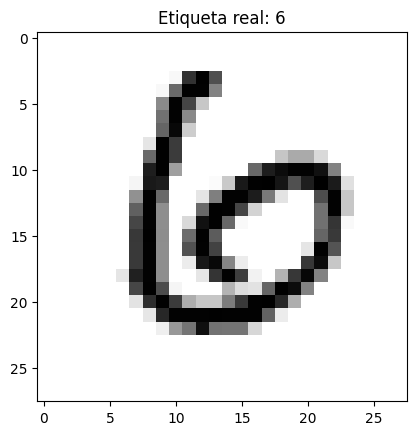

Vector de probabilidades predicho:
[0.11124928 0.01123203 0.21120502 0.02829851 0.02922395 0.06655637
 0.33887056 0.00334836 0.19202437 0.00799148]
Suma de probabilidades: 0.9999998807907104
Dígito predicho: 6


In [22]:
idx = 11  # índice de ejemplo
plt.imshow(X_test[idx].reshape(28, 28), cmap=plt.cm.binary)
plt.title(f'Etiqueta real: {y_test_t[idx].item()}')
plt.show()

model.eval()
with torch.no_grad():
    logits = model(X_test[idx].unsqueeze(0))  # añadimos dimensión batch
    probs = torch.softmax(logits, dim=1).squeeze(0)

print('Vector de probabilidades predicho:')
print(probs.numpy())
print('Suma de probabilidades:', probs.sum().item())

print('Dígito predicho:', torch.argmax(probs).item())